### Astronomy Escape Game

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy import units as u
import pandas as pd
from pandas import DataFrame
import astroquery
from astroquery.skyview import SkyView
from astropy import coordinates as coords
import time
import sys

In [2]:
# Coordinates of Andromeda
ra = 10.7149  # degrees
dec = 41.2659  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

print("Initializing game... please wait!")

image = SkyView.get_images(position = pos, survey = 'DSS', radius=(1.5)*u.deg)

data = image[0][0].data # extracting data

Initializing game... please wait!


In [3]:
class Personalise:
    def __init__(self):
        pass
    def player(self):
        player = input()
        return player
    def slow(self,text):
        for l in text:
            sys.stdout.write(l)
            sys.stdout.flush()
            time.sleep(0.05)
        return 

In [4]:
# initialization
welcome = "Welcome, Astronaut! You are aboard the starship Horizon. I am the central computer of the ship. Identity verification required, please input your name: "
Personalise().slow(welcome)
player = Personalise().player()
time.sleep(0.5)

text = f"Authority recognised, shipwide access granted for Captain {player}!"
    
print()
time.sleep(2)

Welcome, Astronaut! You are aboard the starship Horizon. I am the central computer of the ship. Identity verification required, please input your name: 

 Tara


Authority recognised, shipwide access granted for Captain Tara!


Our mission is to reach the horizons of our galaxy and go beyond. Tara, you will be the first human to visit our neighbor, the Andromeda galaxy! 
Take a look at the viewscreen. This is your destination, doesn't it look beautiful?

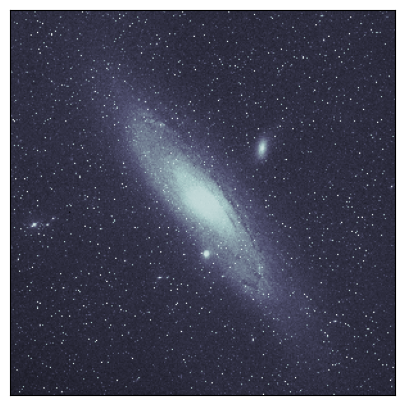

In [5]:
text = f"Our mission is to reach the horizons of our galaxy and go beyond. {player}, you will be the first human to visit our neighbor, the Andromeda galaxy! \n"
Personalise().slow(text)
time.sleep(0.5)
text = "Take a look at the viewscreen. This is your destination, doesn't it look beautiful?"
Personalise().slow(text)
time.sleep(0.5)

fig = plt.figure(figsize = (5,5))
frame = fig.add_subplot(1,1,1)
frame.set_xticks([])
frame.set_yticks([])
frame.imshow(data, origin = 'lower', cmap = 'bone') # bone
fig.show()

In [8]:
time.sleep(3)

text = f"WARNING! Systemwide failure imminent! Navigation and viewscreen control access denied. Input password to regain control:"
Personalise().slow(text)

print()
print()
print('[System information: the password can be guessed by guessing a letter of the alphabet. The computer will tell you if you are going in the right direction. This makes the game analogous to the game "Hangman".]')
time.sleep(0.5)
print()
print()

passwords = np.array(['spectralfluxdensity', 'quadrupolemoment', 'quantumentanglement'])

indx = np.random.randint(0, len(passwords))
password = passwords[indx]

passwordtry = []

for l in password:
    passwordtry.append('_')
    
while '_' in passwordtry:
    
    guess = input()
    passwordsee = '' # this will be shown to the user
    
    for i,p in zip(range(len(password)),password): # checks if the password has the guessed letter
        if p == guess:
            passwordtry[i] = guess # if yes, we "uncover" that character of the password.
    if (guess in password):
        for i in passwordtry:
            passwordsee += i+' '
        print(passwordsee)
    
    else: # if the guessed letter is not in the password
        if data.shape[0] == 30:
            text = f"The time is up! Viewscreen has shut down. All systems are locked. Navigation is not responding. Stand by until the arrival of emergency teams. I am sorry, {player}, you have failed your mission."
            Personalise().slow(text)
            break
        texts = np.array([f"Hurry up, Captain {player}, the viewscreen is shutting down and you are losing control of the ship!",
                          f"Careful, Captain, time will run out soon!", f"This letter is far from a typo! Are you sure you know the password, {player}?"])
        indx = np.random.randint(0,len(texts))
        text = texts[indx]
        Personalise().slow(text)

        n = data.shape[0]
        data = data[0:n-30,:]
        fig = plt.figure(figsize = (5,5))
        frame = fig.add_subplot(1,1,1)
        frame.set_title("VIEWSCREEN")
        frame.set_xticks([])
        frame.set_yticks([])
        frame.imshow(data, origin = 'lower', cmap = 'bone') # bone
        plt.pause(0.05)
        fig.show()

        
passwordfound = ''
for i in range(len(passwordtry)):
    passwordfound += str(passwordtry[i])         
if password == passwordfound:
    text = f"CCorrect password! All navigation functions restored. The mission is a success! Well done, Captain {player}! Have a pleasant journey towards our new home, the Andromeda Galaxy!"
    Personalise().slow(text)

WARNING! Systemwide failure imminent! Navigation and viewscreen control access denied. Input password to regain control:

[System information: the password can be guessed by guessing a letter of the alphabet. The computer will tell you if you are going in the right direction. This makes the game analogous to the game "Hangman".]




 a


_ _ a _ _ _ _ _ _ _ _ _ _ _ _ _ 


 q


q _ a _ _ _ _ _ _ _ _ _ _ _ _ _ 


...

q u a d r u p o l e _ o _ e n _ 


 m


q u a d r u p o l e m o m e n _ 


 t


q u a d r u p o l e m o m e n t 
Correct password. All navigation functions restored. The mission is a success! Well done, Captain Tara! Have a pleasant journey towards our new home, the Andromeda Galaxy!